### Digital Wellness & Lifestyle Behavioral Analysis

**Goal:**
Analyze how sleep, activity and digital enagement impact mental health using behavioral and lifestyle data.

**Objectives:**
- Explore correlations between lifestyle behaviors and wellness outcomes
- Engineer meaningful wellness metrics
- Build an interpretable predictive model

#### Importing Libraries and Initializing Encoders

In [1]:
# Standard Library Imports

import pandas as pd
import numpy as np

#These are the plotting modules and libraries we'll use

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit learn libraries to be used in model training

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


# Initialize encoder
gender_encoder = LabelEncoder()
location_encoder = LabelEncoder()

#command so that plots appear inline in the iPython Notebook
%matplotlib inline

These core Python libraries are used for data manipulation, visualization, and regression modeling

#### Data Loading and Inspection

In [2]:
data_df = pd.read_csv('../data/Tech_Use_Stress_Wellness.csv')
data_df.head()

,user_id,age,gender,daily_screen_time_hours,phone_usage_hours,laptop_usage_hours,tablet_usage_hours,tv_usage_hours,social_media_hours,work_related_hours,...,stress_level,physical_activity_hours_per_week,location_type,mental_health_score,uses_wellness_apps,eats_healthy,caffeine_intake_mg_per_day,weekly_anxiety_score,weekly_depression_score,mindfulness_minutes_per_day
0,1,53,Male,6.8,2.9,2.1,0.5,2.0,2.3,3.0,...,3,4.4,Rural,79.0,True,True,150.4,7.0,3.0,14.0
1,2,66,Female,4.1,2.1,1.6,0.4,0.8,2.8,3.5,...,4,4.1,Rural,71.0,True,True,124.1,7.0,10.0,15.5
2,3,43,Male,4.7,3.6,0.0,0.5,1.4,3.7,3.6,...,6,1.4,Urban,67.0,True,True,218.3,11.0,7.0,19.5
3,4,29,Female,6.0,4.5,0.0,0.2,1.3,4.5,4.0,...,10,0.0,Rural,55.0,True,True,133.7,17.0,14.0,13.9
4,5,57,Male,6.7,3.4,2.0,0.8,1.2,3.8,3.5,...,6,2.8,Urban,62.0,False,False,192.8,5.0,8.0,26.7


In [3]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           5000 non-null   int64  
 1   age                               5000 non-null   int64  
 2   gender                            5000 non-null   object 
 3   daily_screen_time_hours           5000 non-null   float64
 4   phone_usage_hours                 5000 non-null   float64
 5   laptop_usage_hours                5000 non-null   float64
 6   tablet_usage_hours                5000 non-null   float64
 7   tv_usage_hours                    5000 non-null   float64
 8   social_media_hours                5000 non-null   float64
 9   work_related_hours                5000 non-null   float64
 10  entertainment_hours               5000 non-null   float64
 11  gaming_hours                      5000 non-null   float64
 12  sleep_

#### Reviewing the Dataset Structure

In [4]:
# Quick summary transposing the table and rounding decimals to 2 significant figures

data_df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
user_id,5000.0,2500.50,1443.52,1.0,1250.75,2500.50,3750.25,5000.0
age,5000.0,44.70,17.27,15.0,30.00,45.00,60.00,74.0
daily_screen_time_hours,5000.0,5.04,1.84,1.0,3.70,5.00,6.30,10.0
phone_usage_hours,5000.0,1.99,0.89,0.2,1.40,2.00,2.60,5.0
laptop_usage_hours,5000.0,1.56,1.03,0.0,0.70,1.50,2.30,5.0
tablet_usage_hours,5000.0,0.66,0.53,0.0,0.20,0.60,1.00,2.9
tv_usage_hours,5000.0,1.43,0.93,0.0,0.70,1.40,2.10,4.0
social_media_hours,5000.0,3.28,1.20,0.3,2.40,3.60,4.50,4.5
work_related_hours,5000.0,3.36,0.83,0.7,3.10,3.70,3.90,4.5
entertainment_hours,5000.0,1.66,0.66,0.0,1.20,1.60,2.10,3.9


The dataset contains 5,000 individuals and 25 features covering demographics, digital behavior, and mental
health indicators.

#### Data Type Formatting

In [5]:
# Ensure boolean fields are formatted 
bool_columns = ['uses_wellness_apps','eats_healthy']
data_df[bool_columns] = data_df[bool_columns].astype(bool)

# Convert categorical variables
cat_columns = ['gender', 'location_type']
data_df[cat_columns] = data_df[cat_columns].astype('category')

To ensure consistency and optimize memeory usage, boolean fields (uses_wellness_apps, eats_healthy)
were explicity converted to bool, and categorical feilds (gender, location_type) were converted to category data
type.
This step improves the data integrity, enables efficient aggregation and encoding later in the pipeline, and 
prevents type related issues during analysis or model training.

#### Visual Inspection of the Inital Dataset

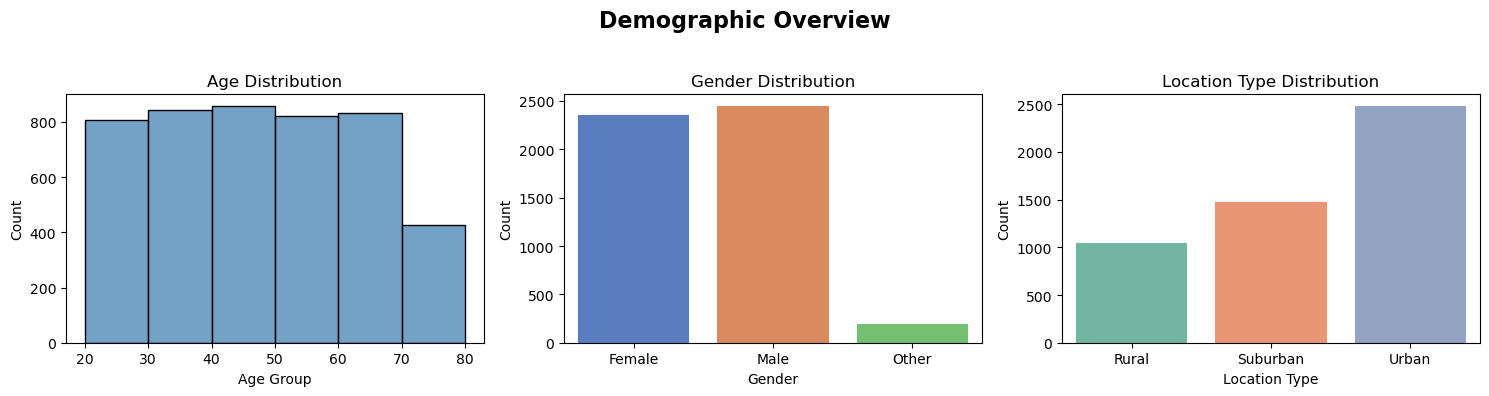

In [6]:
# Setup the figure layout
fig, axes = plt.subplots(1,3, figsize=(15, 4))
fig.suptitle('Demographic Overview', fontsize=16, fontweight ='bold')

# Age Distribution
sns.histplot(data=data_df, x='age', bins=[20,30,40,50,60,70,80], ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')

# Gender Distribution
sns.countplot(data=data_df, x='gender', hue='gender', ax=axes[1], palette='muted')
axes[1].set_title('Gender Distribution')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

# location Type Distribution
sns.countplot(data=data_df, x='location_type', hue='location_type', ax=axes[2], palette='Set2')
axes[2].set_title('Location Type Distribution')
axes[2].set_xlabel('Location Type')
axes[2].set_ylabel('Count')

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()                 

The visualization summarizes the key demographic distribution of the dataset, providing context for interpretiing behavioral and mental trends.
- **Age Distribution:** The participants span a broad range of ages, with representation across all major adjult life stages.  This allows for age-
  based comparisons in mental health and digital behavioral patterns.
- **Gender Distribution:** The dataset includes respondents from all gender categories, ensuring inclusivity and enabling gender-based
  analysis for wellness and screen usage behaviors.
- **Location Type:** Illustrates the distribution of participants across urban, suburban and rural settings, allowing the exploration of
  enviroment type influences on stress, screen habits and mental health outcomes.

By understanding the demographic makeup, we can better contextualize how lifestyle, enviroment and digital engagement correlate with mental health 
indicatorsin the analysis.

#### Exploring Correlation: Age, Social Media Use, and Stress Level
This heatmap highlights relationships between age, social media use, and stress levels.
showing how digital engagement influences stress

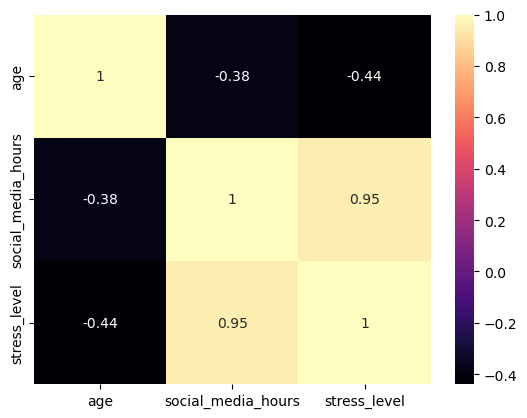

In [7]:
# Creating a new dataframe to capture field values for Age, Social Media, and Stress levels
# then I will generate a heatmap to show the correlation between those fields in terms of stress level

social_stress_df = data_df[['age','social_media_hours','stress_level']]
sns.heatmap(social_stress_df.corr(), annot=True, cmap='magma');

### Feature Engineering: Behavioral & Wellness Metrics
In this section, new variables were drived to better capture patterns of lifestyle balance, digital engagement,
and overall wellness.

In [8]:
# Creating new behavioral features derived from the data

# Total screen time exposure
data_df['total_screen_hours'] = (
                                data_df['phone_usage_hours'] +
                                data_df['laptop_usage_hours']+ 
                                data_df['tablet_usage_hours'] +
                                data_df['tv_usage_hours']
)

# Non-Working screen time
data_df['non_work_screen_hours'] = data_df['total_screen_hours'] - data_df['work_related_hours']

# Ratios capturing how users spend screen time
data_df['social_ratio'] = data_df['social_media_hours'] / data_df['total_screen_hours']
data_df['entertainment_ratio'] = data_df['entertainment_hours'] / data_df['total_screen_hours']
data_df['gaming_ratio'] = data_df['gaming_hours'] / data_df['total_screen_hours']

# Sleep efficiency: (quality per hour of rest)
data_df['sleep_efficiency'] = data_df['sleep_quality']/data_df['sleep_duration_hours']

# Balance between activity and rest
data_df['activity_sleep_balance'] = data_df['physical_activity_hours_per_week'] / (data_df['sleep_duration_hours'] * 7)

data_df['wellness_score'] = (data_df['sleep_quality'] + (data_df['mindfulness_minutes_per_day'] / 10) + 
        data_df['uses_wellness_apps'].astype(int) + data_df['eats_healthy'].astype(int))/4

# Caffeine normalized by awake hours
data_df['caffeine_per_hour_awake'] = (
    data_df['caffeine_intake_mg_per_day'] / (24- data_df['sleep_duration_hours'])
)

# Stress normalized by activity level
data_df['stress_to_activity_ratio'] = (
    data_df['stress_level'] / (data_df['physical_activity_hours_per_week'] + 1)
)

# Combine mental wellness metrics for a balanced index
data_df['mental_health_composite'] = (
    data_df['mental_health_score'] +
    data_df['weekly_anxiety_score'] +
    data_df['weekly_depression_score']
)/3

# Mood vs Stress difference
data_df['mood_vs_stress_diff'] = data_df['mood_rating'] - data_df['stress_level']

# Mindfulness buffering effect
data_df['mindfulness_effect'] = data_df['mindfulness_minutes_per_day'] / (data_df['stress_level'] + 1)

# classifications
#defining age bins and labels 

bins= [0, 20, 30, 40, 50, 60, 70, float('inf')]
labels = ['<20','20-30', '30-40', '40-50', '50-60', '60-70', '70+']

# Create new age group column
data_df['age_group'] = pd.cut(data_df['age'], bins=bins, labels=labels, right=False)

# Encode gender and location type

data_df['gender_encoded'] = gender_encoder.fit_transform(data_df['gender'])
data_df['location_encoded'] = gender_encoder.fit_transform(data_df['location_type'])


These engineered features transform raw behavioral data into structured, interpretable variables that quantify how lifestyle habits and digital use affect mental wellness.

#### Advanced Feature Engineering: Meta-Interactions & Normalized Wellness Scores
This section expands on behavioral modeling by introducing meta-features — combinations of existing variables that capture deeper relationships between activity, stress, and emotional health. These engineered indicators help quantify how multiple behaviors interact to influence overall wellness.

In [9]:
# Adding Meta

data_df['activity_sleep_balance'] = data_df['sleep_quality'] * data_df['physical_activity_hours_per_week']
data_df['screen_x_stress'] = data_df['daily_screen_time_hours'] * data_df['stress_level']
data_df['stress_caffeine_interaction'] = data_df['caffeine_intake_mg_per_day'] * data_df['stress_level']
data_df['emotional_burden'] = (data_df['weekly_anxiety_score'] + data_df['weekly_depression_score'])/2

'''
 Calculate the behavioral score, make a copy in order not to affect the original dataframe
 health behavior score will range between 0 -1
 0 = Poor wellness behavior
 1 = Very healthy wellness behavior
 '''

# Creating a copy of the original data for further processing, while keeping the source file
# This allows us to have a backup in case there is an issue with the copy.

overall_df = data_df.copy()

# Normalize mindfulness_minutes per day to 0-1 scale
scaler = MinMaxScaler()
overall_df['mindfulness_norm'] =  scaler.fit_transform(overall_df[['mindfulness_minutes_per_day']])


overall_df['wellness_score_raw'] = (
    overall_df['sleep_quality'] +
    (overall_df['mindfulness_minutes_per_day']/10) +
    overall_df['uses_wellness_apps'].astype(int) +
    overall_df['eats_healthy'].astype(int)
)/4

overall_df['wellness_score'] = scaler.fit_transform(overall_df[['wellness_score_raw']])

# Compute the composite health behavior score
overall_df['health_behavior_score'] = (
    overall_df['eats_healthy'].astype(int) +
    overall_df['uses_wellness_apps'].astype(int) +
    overall_df['mindfulness_norm']
) / 3

# Check summary of new engineered features
engineered_cols = [
    'total_screen_hours', 'social_ratio', 'sleep_efficiency',
    'activity_sleep_balance', 'caffeine_per_hour_awake',
    'stress_to_activity_ratio', 'health_behavior_score',
    'mindfulness_effect'
]

overall_df[engineered_cols].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
total_screen_hours,5000.0,5.646,1.737,0.400,4.400,5.600,6.800,12.300
social_ratio,5000.0,0.609,0.270,0.058,0.453,0.577,0.727,3.625
sleep_efficiency,5000.0,0.546,0.091,0.132,0.494,0.548,0.606,0.862
activity_sleep_balance,5000.0,11.076,10.103,0.000,2.400,9.200,17.200,55.000
caffeine_per_hour_awake,5000.0,8.548,2.997,0.000,6.547,8.542,10.558,21.595
stress_to_activity_ratio,5000.0,3.194,3.296,0.093,0.588,1.724,5.000,10.000
health_behavior_score,5000.0,0.428,0.267,0.000,0.157,0.425,0.601,1.000
mindfulness_effect,5000.0,4.183,4.035,0.455,1.364,2.667,5.540,21.000


#### Summary Validation:

The engineered columns are summarized statistically to confirm consistent ranges and distributions
before integration into predictive modeling. Together, these meta-features provide a holistic behavioral 
profile, quantifying how stress, lifestyle, and digital habits interact to shape mental wellness outcomes.

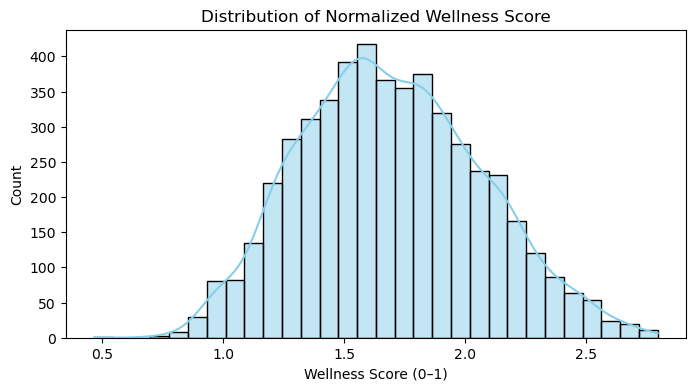

In [10]:
# Generate a histogram to review the Wellness Score to see how the scores
# are distributed across the population

plt.figure(figsize=(8,4))
sns.histplot(data_df['wellness_score'], kde=True, bins=30, color='skyblue')
plt.title("Distribution of Normalized Wellness Score")
plt.xlabel("Wellness Score (0–1)")
plt.ylabel("Count")
plt.show()


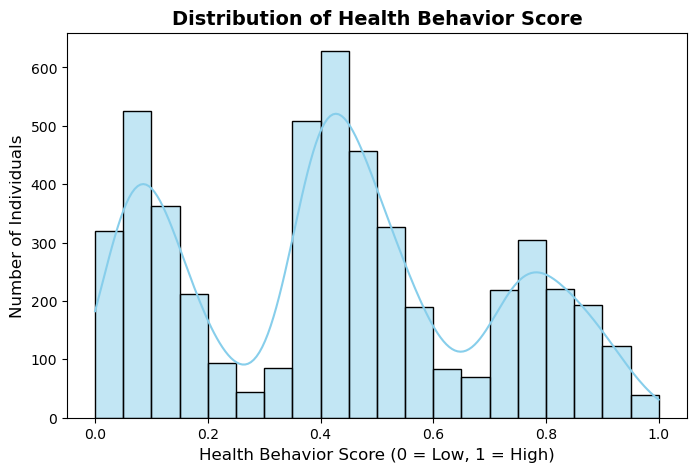

In [11]:
# Plotting a histogram of the health score distribution within the data set

plt.figure(figsize=(8,5))
sns.histplot(overall_df['health_behavior_score'], bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Health Behavior Score', fontsize=14, weight='bold')
plt.xlabel('Health Behavior Score (0 = Low, 1 = High)', fontsize=12)
plt.ylabel('Number of Individuals', fontsize=12)
plt.show()

**Insight:**
The distriubiton of the Health Behavior Scores show three distinct clusters, indicating groups with poor, moderate
and strong wellness habits.  Suggesting an opportunity to anlyze how these behavior levels relate to mental health
outcomes.

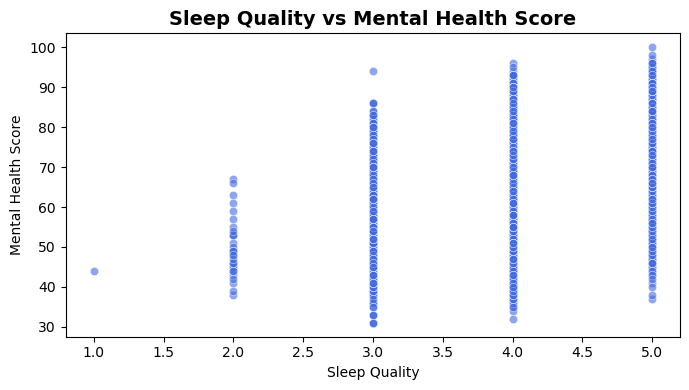

In [12]:
# Scatter plot for sleep quality vs mental health score
plt.figure(figsize=(7,4))
sns.scatterplot(data=overall_df, x='sleep_quality', y='mental_health_score', alpha=0.6, color='royalblue')
plt.title('Sleep Quality vs Mental Health Score', fontsize=14, weight='bold')
plt.xlabel('Sleep Quality')
plt.ylabel('Mental Health Score')
plt.tight_layout()
plt.show()


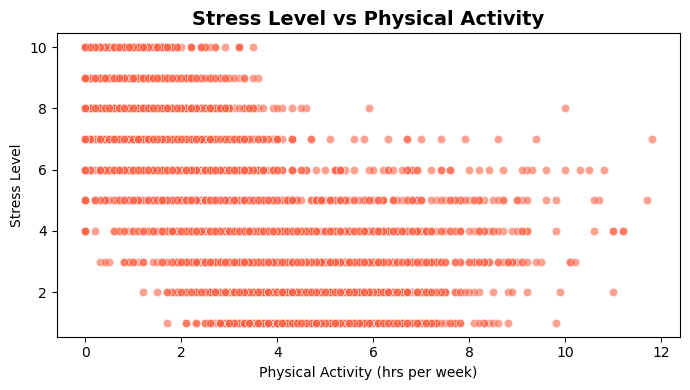

In [13]:
# Stress vs Physical Activity

plt.figure(figsize=(7,4))
sns.scatterplot(data=data_df, x='physical_activity_hours_per_week', y='stress_level', alpha=0.6, color='tomato')
plt.title('Stress Level vs Physical Activity', fontsize=14, weight='bold')
plt.xlabel('Physical Activity (hrs per week)')
plt.ylabel('Stress Level')
plt.tight_layout()
plt.show()


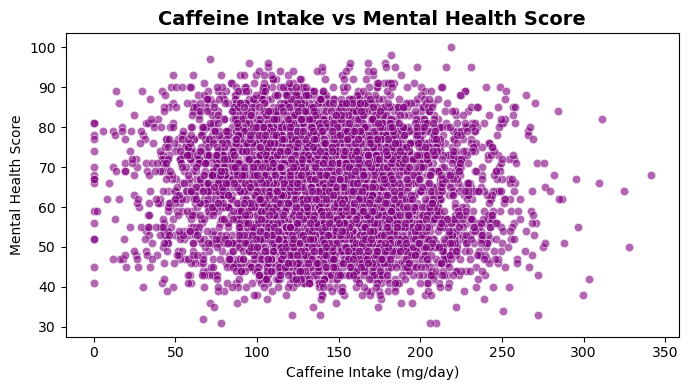

In [14]:
# Scatter plot for caffeine intake vs mental health

plt.figure(figsize=(7,4))
sns.scatterplot(data=overall_df, x='caffeine_intake_mg_per_day', y='mental_health_score', alpha=0.6, color='purple')
plt.title('Caffeine Intake vs Mental Health Score', fontsize=14, weight='bold')
plt.xlabel('Caffeine Intake (mg/day)')
plt.ylabel('Mental Health Score')
plt.tight_layout()
plt.show()


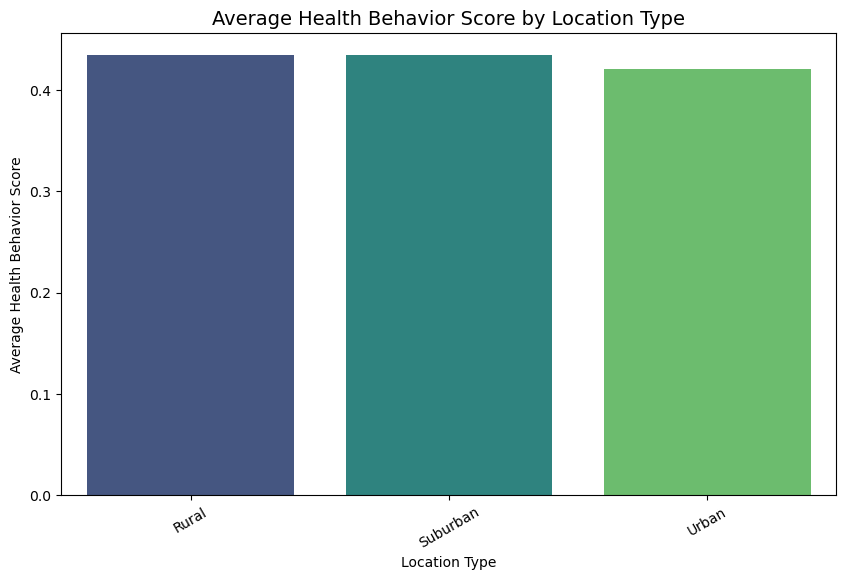

In [15]:
# Plot and Review the distribution of Average Health Scores by Location 

plt.figure(figsize=(10,6))
sns.barplot(data=overall_df, x='location_type', y='health_behavior_score', estimator='mean', errorbar=None, hue='location_type', palette='viridis')
plt.title("Average Health Behavior Score by Location Type", fontsize=14)
plt.xlabel("Location Type")
plt.ylabel("Average Health Behavior Score")
plt.xticks(rotation=30)
plt.show()


**Insight:**
The location types appear to similar for all 3 categories, suggesting that location type has little impact related to behavioral health.

In [16]:
# Correlation calculation
corr = overall_df[['health_behavior_score', 'mental_health_score']].corr()
print(corr)


                       health_behavior_score  mental_health_score
health_behavior_score               1.000000             0.412386
mental_health_score                 0.412386             1.000000


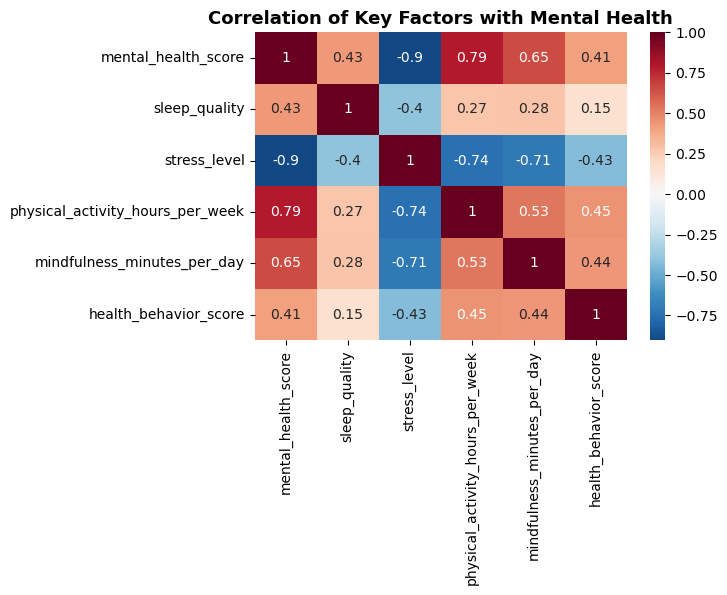

In [17]:
key_corr = overall_df[['mental_health_score','sleep_quality','stress_level',
                       'physical_activity_hours_per_week','mindfulness_minutes_per_day',
                       'health_behavior_score']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(key_corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation of Key Factors with Mental Health', fontsize=13, weight='bold')
plt.show()


**Insight:**  

Mental health positively correlates with sleep quality, mindfulness, and health behavior score, and correlates negatively with stress level.

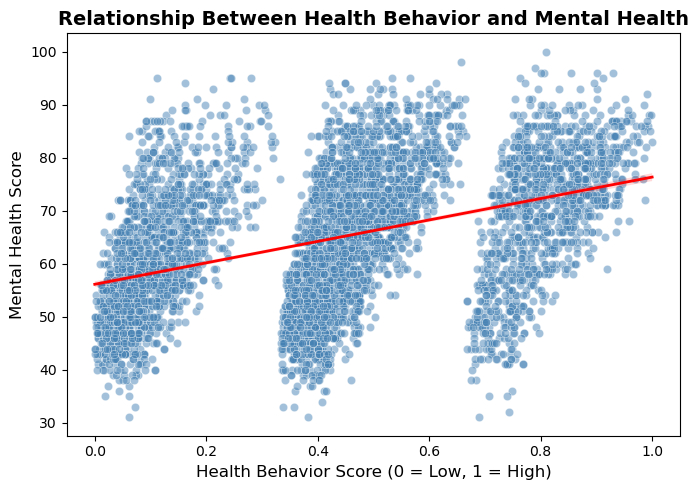

In [18]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=overall_df,
    x='health_behavior_score',
    y='mental_health_score',
    alpha=0.5,
    color='steelblue'
)
# Adding a regression line to the scatter plot        
sns.regplot(
    data=overall_df,
    x='health_behavior_score',
    y='mental_health_score',
    scatter=False,
    color='red',
    line_kws={'lw':2}
)
plt.title('Relationship Between Health Behavior and Mental Health', fontsize=14, weight='bold')
plt.xlabel('Health Behavior Score (0 = Low, 1 = High)', fontsize=12)
plt.ylabel('Mental Health Score', fontsize=12)
plt.tight_layout()
plt.show()


**Insight:**  

This scatter plot illustrates a clear positive relationship between health behavior and mental health,
As inidviduals adopt healthier habits, such as mindful practices, balnced diets, and wellness app use,
their mental health scores tend to improve.  
This supports the model's assumption that lifestyle behaviors are significant predictors of mental wellness.

### Model Training and Coeffiecients

#### Defining Predictors and Target

In [19]:
# Define target and predictors

X = overall_df[[
    'health_behavior_score',
    'sleep_quality',
    'sleep_duration_hours',
    'stress_level',
    'physical_activity_hours_per_week',
    'caffeine_intake_mg_per_day',
    'mindfulness_minutes_per_day'
]]

y = overall_df['mental_health_score']

### Train Regression Model

In [20]:
# Split into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state=42
)

In [21]:
# Initialize and fit model

model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
# Predictions and evaluation

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")


R² Score: 0.856
RMSE: 5.071


The model explains ~86% of the variance in mental health scores, demonstrating strong predictive capability.

#### Feature Importance Visualization

In [23]:
# Check feature importance, will show the strongest positive or negative impact on mental health
# Store the coefficients for analysis

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(importance)

                            Feature  Coefficient
1                     sleep_quality     1.839672
4  physical_activity_hours_per_week     1.505723
2              sleep_duration_hours     0.214252
6       mindfulness_minutes_per_day     0.022123
5        caffeine_intake_mg_per_day    -0.002084
0             health_behavior_score    -0.741572
3                      stress_level    -2.970741


Sleep quality and physical activity have the strongest postitive impact, while stress and caffeine reduce wellness scores.

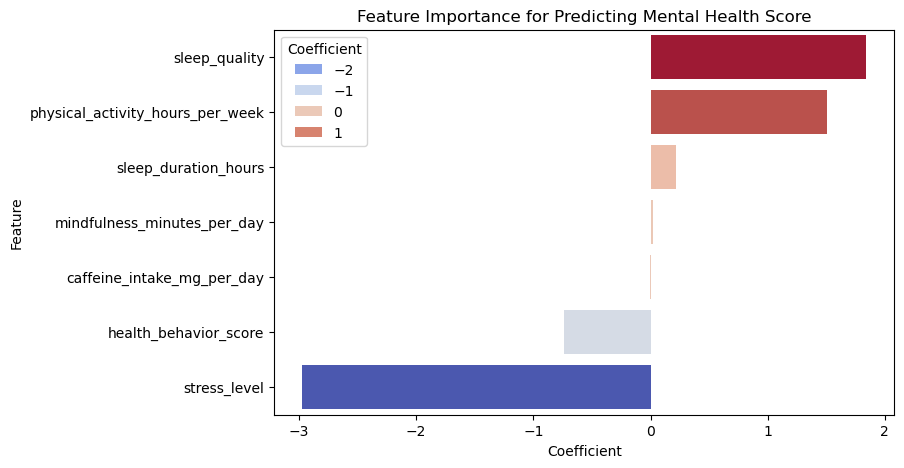

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(data=importance, x='Coefficient', y='Feature', hue='Coefficient', palette='coolwarm')
plt.title("Feature Importance for Predicting Mental Health Score")
plt.show()


#### Determining the relationships between the features by using correlation matrix

In [25]:
overall_df[['health_behavior_score', 'sleep_quality', 
         'physical_activity_hours_per_week', 
         'mindfulness_minutes_per_day']].corr()

,health_behavior_score,sleep_quality,physical_activity_hours_per_week,mindfulness_minutes_per_day
health_behavior_score,1.000000,0.152700,0.448524,0.437235
sleep_quality,0.152700,1.000000,0.272289,0.283443
physical_activity_hours_per_week,0.448524,0.272289,1.000000,0.534564
mindfulness_minutes_per_day,0.437235,0.283443,0.534564,1.000000


#### Model Refinement: Standardized LInear Regression

After creating and validating engineered behavioral features, this step re-runs the regression model using **standardized predictors**.
The goal is to ensure that each feature contributes to the model on a **comparable scale**, allowing for meaningful interpretation of
coefficients.

>The refined model provides a fair and interpretable framework for comparing behavioral predictors,
>eliminating the distortion caused by different measurement scales.

In [26]:
# Select the features we created earlier for standardization
features = [
    'health_behavior_score', 
    'sleep_quality', 
    'sleep_duration_hours', 
    'stress_level', 
    'physical_activity_hours_per_week',
    'caffeine_intake_mg_per_day',
    'mindfulness_minutes_per_day'
]

X = overall_df[features]
y = overall_df['mental_health_score']

# Standardize X and y
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the model on scaled features
model_std = LinearRegression()
model_std.fit(X_scaled, y)

# Build standardized coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Standardized Coefficient': model_std.coef_
}).sort_values(by='Standardized Coefficient', ascending=False)

print(coef_df)


                            Feature  Standardized Coefficient
4  physical_activity_hours_per_week                  3.471991
1                     sleep_quality                  1.195217
6       mindfulness_minutes_per_day                  0.146605
2              sleep_duration_hours                  0.090346
5        caffeine_intake_mg_per_day                 -0.135639
0             health_behavior_score                 -0.184620
3                      stress_level                 -8.724020


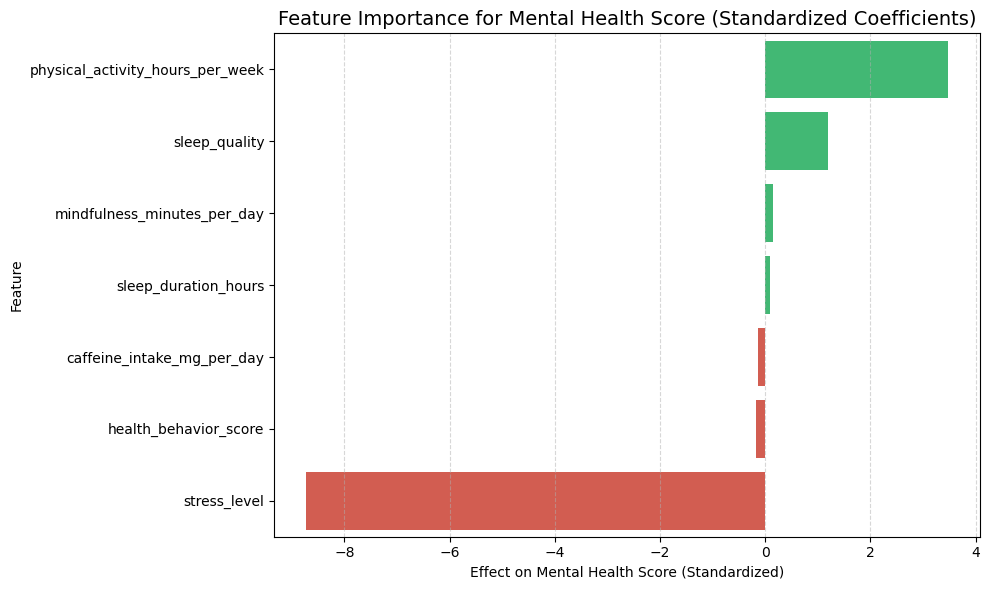

In [27]:
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Standardized Coefficient']]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df,
    x='Standardized Coefficient',
    y='Feature',
    hue='Feature',
    palette=colors

)
plt.title('Feature Importance for Mental Health Score (Standardized Coefficients)', fontsize=14)
plt.xlabel('Effect on Mental Health Score (Standardized)')
plt.ylabel('Feature')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Writing the New Data Frame to File

In [28]:
overall_df.to_csv('../data/mental_health_features.csv',index=False)

#### Write Coefficients and Features to Seperate File

In [29]:
# Generating a new data frame with the feature importance
# The objective is to generate the absolute value used to determine the highest impact regardless of sign
# Once the data frame is generated, this will be written into a separate file.

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

# Optional: Add absolute values for sorting
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

# Show preview
print(feature_importance)
# Write to file
feature_importance.to_csv('../data/feature_importance.csv', index=False)

                            Feature  Coefficient  Abs_Coefficient
3                      stress_level    -2.970741         2.970741
1                     sleep_quality     1.839672         1.839672
4  physical_activity_hours_per_week     1.505723         1.505723
0             health_behavior_score    -0.741572         0.741572
2              sleep_duration_hours     0.214252         0.214252
6       mindfulness_minutes_per_day     0.022123         0.022123
5        caffeine_intake_mg_per_day    -0.002084         0.002084


### Insights Summary
- Sleep and activity improve mental health outcomes
- Stress is the strongest negative predictor
- Mindfulness and wellness habits enhance balance
- Caffeine and poor sleep efficiency lower wellness